<a href="https://colab.research.google.com/github/rabbitego/copying-mechanism/blob/main/Capstone_1_NHANES_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!wget https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv
!wget https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv


--2026-02-10 17:48:22--  https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 144073 (141K) [text/plain]
Saving to: ‘nhanes_adult_male_bmx_2020.csv’

nhanes_adult_male_b 100%[===================>] 140.70K  --.-KB/s    in 0.02s   

2026-02-10 17:48:22 (5.95 MB/s) - ‘nhanes_adult_male_bmx_2020.csv’ saved [144073/144073]

--2026-02-10 17:48:22--  https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected

In [22]:
import pandas as pd
import numpy as np

male_df = pd.read_csv("nhanes_adult_male_bmx_2020.csv")
female_df = pd.read_csv("nhanes_adult_female_bmx_2020.csv")


ParserError: Error tokenizing data. C error: Expected 1 fields in line 19, saw 7


In [23]:
import pandas as pd
import numpy as np

male_df = pd.read_csv(
    "nhanes_adult_male_bmx_2020.csv",
    sep=",",
    engine="python",
    on_bad_lines="skip",
    comment="#"
)

female_df = pd.read_csv(
    "nhanes_adult_female_bmx_2020.csv",
    sep=",",
    engine="python",
    on_bad_lines="skip",
    comment="#"
)


In [24]:
male_df.head()
male_df.shape


(4081, 7)

In [25]:
male = male_df.to_numpy()
female = female_df.to_numpy()

male.shape, female.shape
#The male and female datasets were converted from pandas DataFrames into NumPy matrices to facilitate efficient numerical computations.


((4081, 7), (4221, 7))

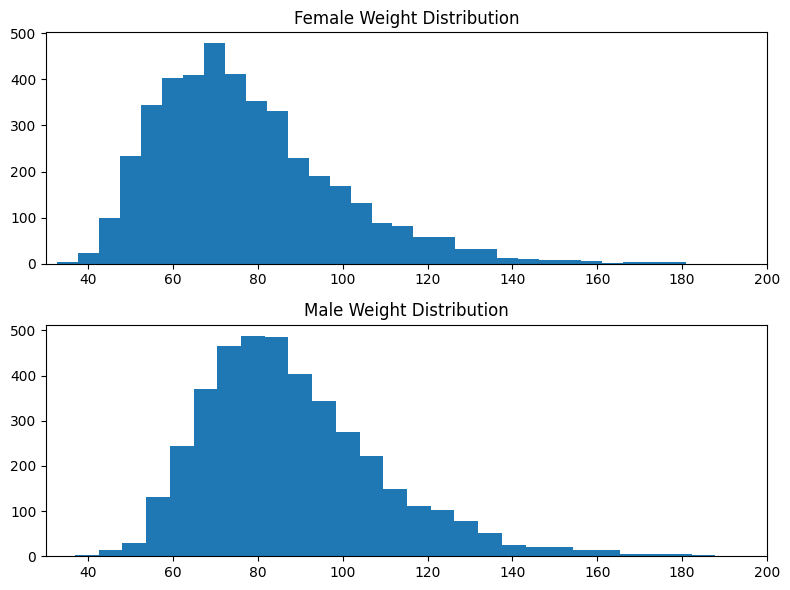

In [26]:
#HISTOGRAMS
import matplotlib.pyplot as plt

female_weights = female[:, 0]
male_weights = male[:, 0]

plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=30)
plt.title("Female Weight Distribution")
plt.xlim(30, 200)

plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=30)
plt.title("Male Weight Distribution")
plt.xlim(30, 200)

plt.tight_layout()
plt.show()
#(The histograms show that male participants generally have higher body weights compared to female participants.
#The male weight distribution is shifted towards higher values and exhibits slightly greater spread, indicating higher variability.
#Both distributions appear moderately right-skewed, suggesting the presence of heavier individuals in both groups.

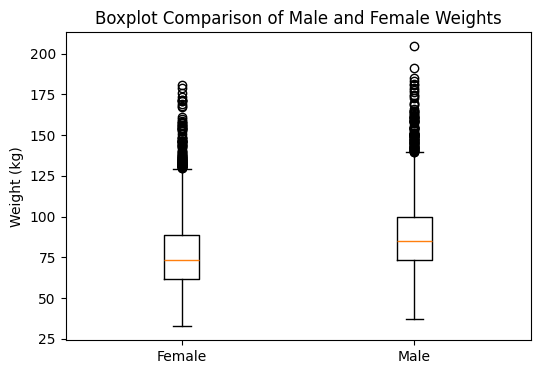

In [27]:
#BOXPLOT
plt.figure(figsize=(6, 4))
plt.boxplot(
    [female_weights, male_weights],
    tick_labels=["Female", "Male"]
)
plt.title("Boxplot Comparison of Male and Female Weights")
plt.ylabel("Weight (kg)")
plt.show()

#The boxplot comparison indicates that the median body weight of males is higher than that of females.
#Outliers are observed in both groups, representing individuals with unusually high or low body weight.

In [28]:
#BASIC STATISTICS
from scipy.stats import skew, kurtosis

def describe(data):
    return {
        "Mean": np.mean(data),
        "Median": np.median(data),
        "Std Dev": np.std(data),
        "Skewness": skew(data),
        "Kurtosis": kurtosis(data)
    }

female_stats = describe(female_weights)
male_stats = describe(male_weights)

female_stats, male_stats

#Male participants have a higher mean and median body weight compared to females.
#The standard deviation is also higher for males, indicating greater variability.
#Positive skewness in both distributions suggests a longer right tail, while kurtosis values indicate moderately peaked distributions.


({'Mean': np.float64(77.40379057095475),
  'Median': np.float64(73.6),
  'Std Dev': np.float64(21.54250829019315),
  'Skewness': np.float64(1.03336107186799),
  'Kurtosis': np.float64(1.4009683480659731)},
 {'Mean': np.float64(88.36454300416565),
  'Median': np.float64(85.0),
  'Std Dev': np.float64(21.418936717962495),
  'Skewness': np.float64(0.9842810741662347),
  'Kurtosis': np.float64(1.4742884754078238)})

In [29]:
#ADDING BMI COLUMN (FEMALE)
female_height_m = female[:, 1] / 100
female_bmi = female[:, 0] / (female_height_m ** 2)

female = np.column_stack((female, female_bmi))
#Body Mass Index (BMI) was calculated for female participants and appended as an additional column to the dataset.

In [30]:
#STANDARDIZE FEMALE DATA (Z-SCORE)
zfemale = (female - np.mean(female, axis=0)) / np.std(female, axis=0)

#The female dataset was standardized using z-score normalization to ensure that all variables are on a comparable scale.


In [31]:
#Picking Required Columns (from female)

#Weight

#Height

#Waist

#Hip

#BMI


# selecting required columns
female_weight = female[:, 0]
female_height = female[:, 1]
female_waist = female[:, 6]
female_hip = female[:, 5]
female_bmi = female[:, 7]

#Selected key anthropometric variables including weight, height, waist circumference, hip circumference, and BMI for multivariate analysis.

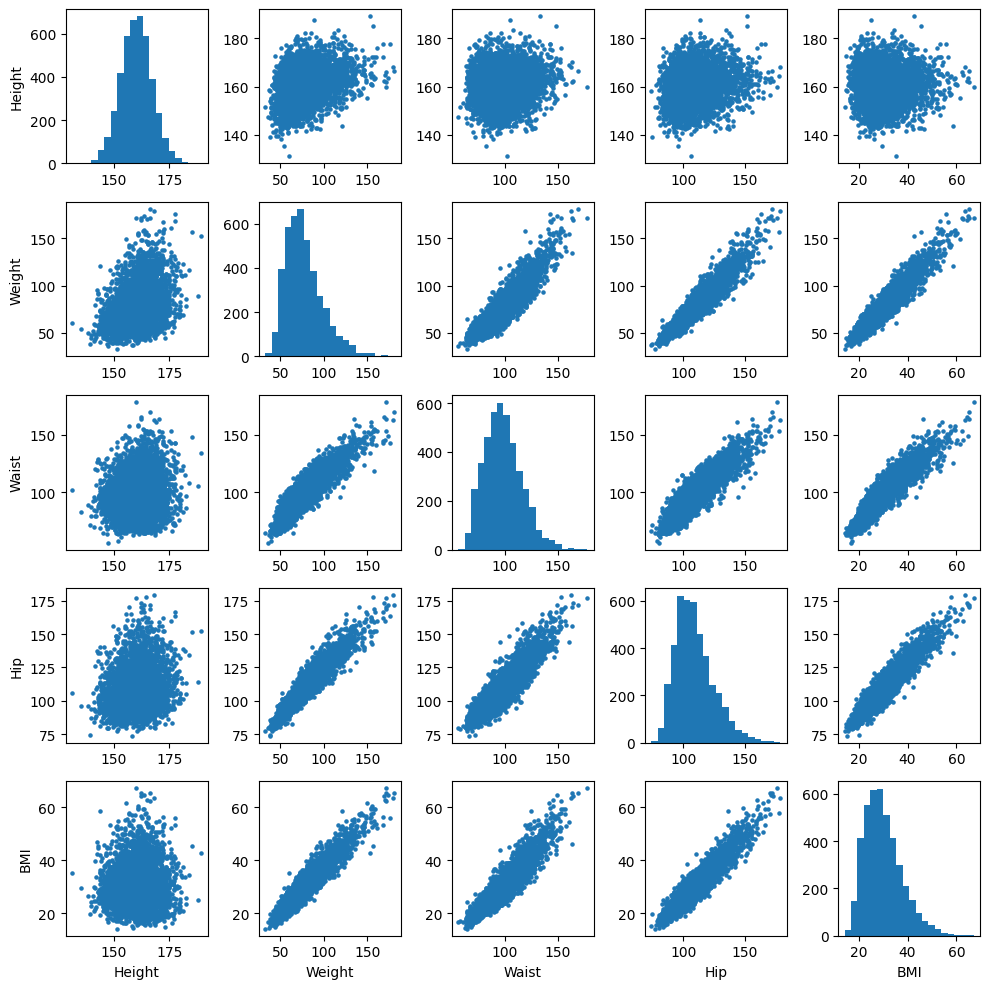

In [32]:
#Scatterplot Matrix
import matplotlib.pyplot as plt

data = [female_height, female_weight, female_waist, female_hip, female_bmi]
labels = ["Height", "Weight", "Waist", "Hip", "BMI"]

plt.figure(figsize=(10, 10))

for i in range(len(data)):
    for j in range(len(data)):
        plt.subplot(5, 5, i*5 + j + 1)
        if i == j:
            plt.hist(data[i], bins=20)
        else:
            plt.scatter(data[j], data[i], s=5)

        if i == 4:
            plt.xlabel(labels[j])
        if j == 0:
            plt.ylabel(labels[i])

plt.tight_layout()
plt.show()

#The scatterplot matrix illustrates pairwise relationships among height, weight, waist circumference, hip circumference, and BMI in female participants.
#Strong positive relationships are visible between weight, waist circumference, hip circumference, and BMI.
#Height shows weaker association with fat-related measures compared to circumferences and BMI.


In [33]:
#Correlation (Pearson + Spearman)

from scipy.stats import pearsonr, spearmanr

variables = [female_height, female_weight, female_waist, female_hip, female_bmi]
names = ["Height", "Weight", "Waist", "Hip", "BMI"]

print("Pearson Correlation:\n")
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        r, _ = pearsonr(variables[i], variables[j])
        print(f"{names[i]} vs {names[j]} : {r:.2f}")

print("\nSpearman Correlation:\n")
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        r, _ = spearmanr(variables[i], variables[j])
        print(f"{names[i]} vs {names[j]} : {r:.2f}")

 #Pearson correlation results indicate strong linear associations between weight, waist circumference, hip circumference, and BMI.
#Spearman correlation values follow a similar pattern, confirming that these relationships remain strong even when rank-based correlations are considered.
#The consistency between both methods suggests robust relationships among body fat–related measurements.


Pearson Correlation:

Height vs Weight : 0.35
Height vs Waist : 0.13
Height vs Hip : 0.20
Height vs BMI : 0.03
Weight vs Waist : 0.90
Weight vs Hip : 0.95
Weight vs BMI : 0.95
Waist vs Hip : 0.90
Waist vs BMI : 0.92
Hip vs BMI : 0.94

Spearman Correlation:

Height vs Weight : 0.34
Height vs Waist : 0.11
Height vs Hip : 0.21
Height vs BMI : 0.02
Weight vs Waist : 0.90
Weight vs Hip : 0.95
Weight vs BMI : 0.94
Waist vs Hip : 0.89
Waist vs BMI : 0.92
Hip vs BMI : 0.93


In [34]:
# Female
female_waist_height = female[:, 6] / female[:, 1]
female_waist_hip = female[:, 6] / female[:, 5]
female = np.column_stack((female, female_waist_height, female_waist_hip))

# Male
male_waist_height = male[:, 6] / male[:, 1]
male_waist_hip = male[:, 6] / male[:, 5]
male = np.column_stack((male, male_waist_height, male_waist_hip))

#Waist-to-height and waist-to-hip ratios were computed for both male and female participants to assess fat distribution and related health risk more effectively than weight alone.


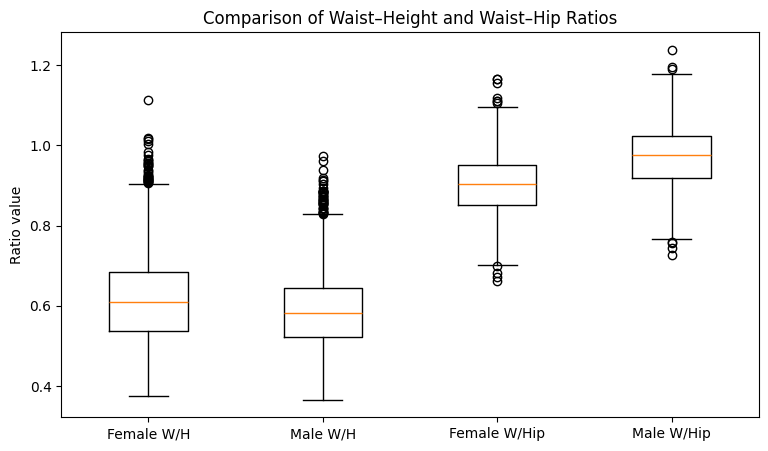

In [35]:
#BOXPLOT WITH 4 BOXES
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

data_to_plot = [
    female[:, -2],  # Female waist-height
    male[:, -2],    # Male waist-height
    female[:, -1],  # Female waist-hip
    male[:, -1]     # Male waist-hip
]

plt.boxplot(
    data_to_plot,
    tick_labels=[
        "Female W/H", "Male W/H",
        "Female W/Hip", "Male W/Hip"
    ]
)

plt.ylabel("Ratio value")
plt.title("Comparison of Waist–Height and Waist–Hip Ratios")
plt.show()

#The boxplot shows that males generally have higher waist-to-height and waist-to-hip ratios compared to females.
#This suggests greater central fat accumulation among males, which is associated with increased metabolic risk.


BMI

Advantages

Easy to calculate

Useful for population-level screening

Disadvantages

Does not distinguish fat from muscle

Does not capture fat distribution

Waist–Height Ratio

Advantages

Good indicator of central obesity

Strongly linked to cardiovascular risk

Disadvantages

Requires accurate waist measurement

Less commonly used in routine checkups

Waist–Hip Ratio

Advantages

Reflects body fat distribution

Useful for predicting metabolic disorders

Disadvantages

Hip measurement variability

Less sensitive to overall obesity

In [36]:
# BMI column index in zfemale is 7
bmi_index = 7

# sort indices by BMI
sorted_idx = np.argsort(zfemale[:, bmi_index])

lowest_5 = zfemale[sorted_idx[:5]]
highest_5 = zfemale[sorted_idx[-5:]]

print("Lowest 5 BMI (standardized):\n", lowest_5)
print("\nHighest 5 BMI (standardized):\n", highest_5)


Lowest 5 BMI (standardized):
 [[-2.07978523 -1.22299143 -1.5478402  -1.16905675 -2.1947611  -2.0405496
  -1.94212128 -2.05024028]
 [-1.88017988 -0.18929313 -1.71835247  0.38637892 -2.4443617  -1.85491922
  -2.05708015 -1.99487987]
 [-1.53667299  1.80730222  0.62619127  0.5730312  -2.26607556 -1.6756899
  -1.7064556  -1.97088383]
 [-1.843044   -0.26009438 -0.22637009  0.51081377 -2.30173278 -2.25178417
  -1.85590213 -1.94177591]
 [-1.61094475  0.88688592 -0.09848588  0.47970506 -2.21258971 -1.82931504
  -1.71220354 -1.89319577]]

Highest 5 BMI (standardized):
 [[ 4.2472403   0.29215539  1.86240524 -0.98240447  2.3693641   4.10445598
   3.81731803  4.39649161]
 [ 4.45612963  0.50455915  1.69189297 -1.13794804  3.34993787  3.98283607
   2.90339503  4.46201122]
 [ 4.34936397  0.27799514  2.84285081  1.94181459  4.36616887  3.9188256
   3.75409065  4.51466896]
 [ 4.8042785   0.88688592  2.11817365  1.81737973  3.77782461  4.02124236
   4.08172343  4.54270932]
 [ 4.36328993 -0.03353037 -0.05

Individuals with the lowest BMI show negative standardized values for weight and circumferences, indicating lean body composition.
Individuals with the highest BMI display strongly positive standardized values for waist and hip circumferences, reflecting increased adiposity and higher health risk.